## CS5004 E-tivity 3

Name: Sean Noonan

StudentId: 2300159

# Task 1:
Windy grid learning


In [5]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import random

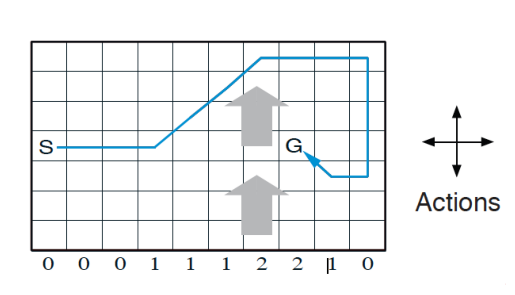

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = "windy_gridworld.png"
image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.axis("off")  # Hide axis labels
plt.show()


Person starts at S, moves at random until they reach G. There is a wind that deflects their movement given for each column by (0,0,0,1,1,1,2,2,1,0). Each move has a reward of -1.

We want to find an optimal policy from moving to start to goal

In [7]:
# Follow Q-learning algorithm

# Gridworld dimensions
# 7x10 gid
rows = 7
cols = 10
# We begin midway down the first column and want to finish
start = (3, 0)
goal = (3, 7)

# Wind strength per column
wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

# Actions: Up, Down, Left, Right
actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # Right, Left, Up, Down

In [8]:
# Set up
episodes = 200 #  At my discretion
epsilon = 0.1 # deviation from greedy
alpha = 0.5   # Learning rate
gamma = 1.0   # reward difference decay rate

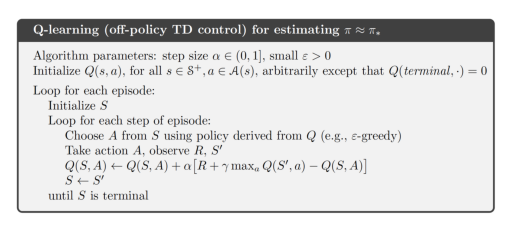

In [9]:
# Load the image
image_path1 = "Qlearning_algorithm.png"  # Replace with your image path
image1 = Image.open(image_path1)

# Display the image
plt.imshow(image1)
plt.axis("off")  # Hide axis labels
plt.show()

In [10]:
# Function to choose an action using epsilon-greedy policy - step in above algorithm
def choose_At(state):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # deviate epsilon percent of time - exploration
    else:
        return max(Qtable[state], key=Qtable[state].get)  # Take max value - greedy policy to take best it has seen

In [11]:
# Function to take action A and observe new state S'= St1, reward Rt
def take_At(St, At):
    row, col = St
    d_row, d_col = At

    # Apply action
    new_row = min(max(row + d_row - wind[col], 0), rows - 1)
    new_col = min(max(col + d_col, 0), cols - 1)

    # Reward is always -1 per move
    Rt = -1

    return (new_row, new_col), Rt

In [12]:
# Loop for each episode
E_Gt = []

paths = []  # Store routes

# Q table creation -  Set all to zero
Qtable = {}
for row in range(rows):
    for col in range(cols):
        Qtable[(row, col)] = {action: 0 for action in actions}

for episode in range(episodes):
    St = start
    Gt = 0
    path = [St]  # Lets track the agent's path, initialize it at start point

    while St != goal:
        At = choose_At(St)
        St1, Rt = take_At(St, At)
        Gt += Rt

        # Q-learning update equation
        best_At1 = max(Qtable[St1], key=Qtable[St1].get)
        Qtable[St][At] += alpha * (Rt + gamma * Qtable[St1][best_At1] - Qtable[St][At])

        # Update state to new state
        St = St1
        path.append(St)  # Append new state

    E_Gt.append(Gt)
    # Store path for visualization (only for last episode)
    # if episode == episodes - 1:
    paths.append(path)

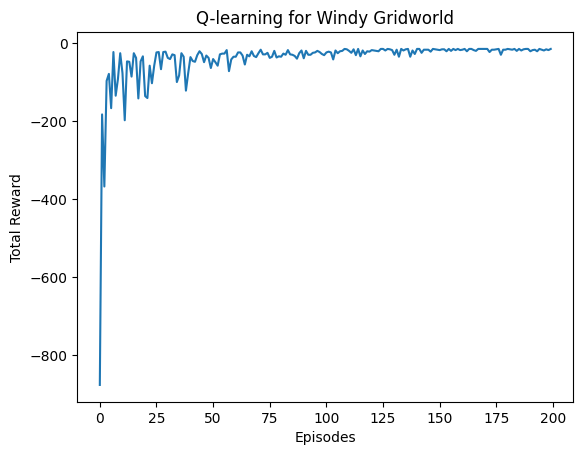

In [13]:
# Plotting learning curve
plt.plot(E_Gt)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning for Windy Gridworld")
plt.show()

In [14]:
# Print last 10 values
print(E_Gt[-10:])

[-21, -18, -17, -21, -15, -17, -19, -16, -18, -15]


We can see that the total reward converges to around -15. This is 15 moves.

It takes about 100 episodes to get to converge to this optimal route policy in a steady mannor.

Lets take a look at the optimal path

In [15]:
max_reward_index = E_Gt.index(max(E_Gt))  # Get index of episode with max reward
print(max_reward_index)
optimal_path = paths[max_reward_index]  # Path corresponding to max reward


108


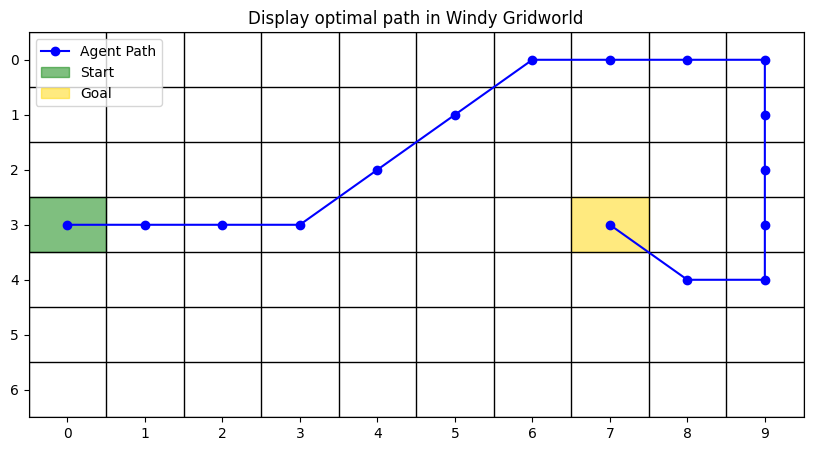

In [16]:
# Function to plot the path correctly
def plot_path(grid_size, path, title="Final Agent Path in Windy Gridworld"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw grid
    for i in range(grid_size[0] + 1):
        ax.plot([-0.5, grid_size[1] - 0.5], [i - 0.5, i - 0.5], "k", lw=1)
    for j in range(grid_size[1] + 1):
        ax.plot([j - 0.5, j - 0.5], [-0.5, grid_size[0] - 0.5], "k", lw=1)

    # Plot the path ensuring it starts at START and ends at GOAL
    path_x, path_y = zip(*path)
    ax.plot(path_y, path_x, marker="o", color="blue", markersize=6, label="Agent Path", linestyle="-")

    # Mark start and goal
    ax.add_patch(plt.Rectangle((start[1] - 0.5, start[0] - 0.5), 1, 1, color="green", alpha=0.5, label="Start"))
    ax.add_patch(plt.Rectangle((goal[1] - 0.5, goal[0] - 0.5), 1, 1, color="gold", alpha=0.5, label="Goal"))

    # Adjust plot limits
    ax.set_xlim(-0.5, grid_size[1] - 0.5)
    ax.set_ylim(grid_size[0] - 0.5, -0.5)  # Invert y-axis for correct display
    ax.set_xticks(range(grid_size[1]))
    ax.set_yticks(range(grid_size[0]))
    ax.set_xticklabels(range(grid_size[1]))
    ax.set_yticklabels(range(grid_size[0]))
    ax.legend()
    ax.set_title(title)

    plt.show()

# Plot path for the last episode
plot_path((rows, cols), optimal_path, "Display optimal path in Windy Gridworld")

We can see the 15 optimal steps taken to get to the Goal.

**Lets try this with Sarsa**

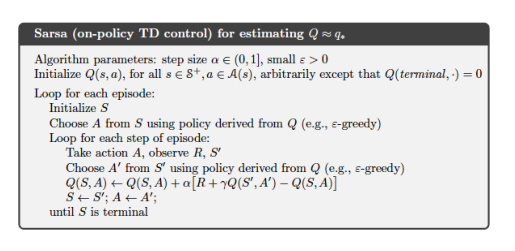

In [17]:
# Load the image
image_path2 = "sarsa.png"  # Replace with your image path
image2 = Image.open(image_path2)

# Display the image
plt.imshow(image2)
plt.axis("off")  # Hide axis labels
plt.show()

In [18]:
# Set up
episodes = 200 #  At my discretion
epsilon = 0.1 # deviation from greedy
alpha = 0.1   # Learning rate
gamma = 0.   # reward difference decay rate

In [19]:
E_GtS = []  # Store total rewards per episode
pathsS = []  # Store routes

# Q table creation - Set all values to zero initially
QtableS = {}
for row in range(rows):
    for col in range(cols):
        QtableS[(row, col)] = {action: 0 for action in actions}

for episode in range(episodes):
    St = start
    At = choose_At(St)  # Choose first action (on-policy)
    Gt = 0
    path = [St]  # Track agent's path, initialize at start point

    while St != goal:
        St1, Rt = take_At(St, At)  # Take step, observe new state and reward
        At1 = choose_At(St1)  # Choose A_{t+1} using epsilon-greedy

        # SARSA update equation
        Qtable[St][At] += alpha * (Rt + gamma * Qtable[St1][At1] - Qtable[St][At])

        # Update for next iteration
        St, At = St1, At1
        Gt += Rt
        path.append(St)  # Append new state

    E_GtS.append(Gt)  # Store total episode reward
    pathsS.append(path)  # Store path for visualization



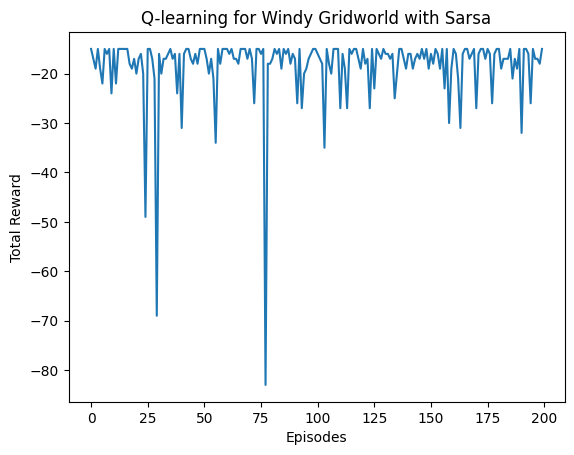

In [20]:
# Plotting learning curve
plt.plot(E_GtS)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning for Windy Gridworld with Sarsa")
plt.show()

This is extremely unstable.

Sarsa is more conservative than Q learning. Q learning takes risks by asusming the best possible action.

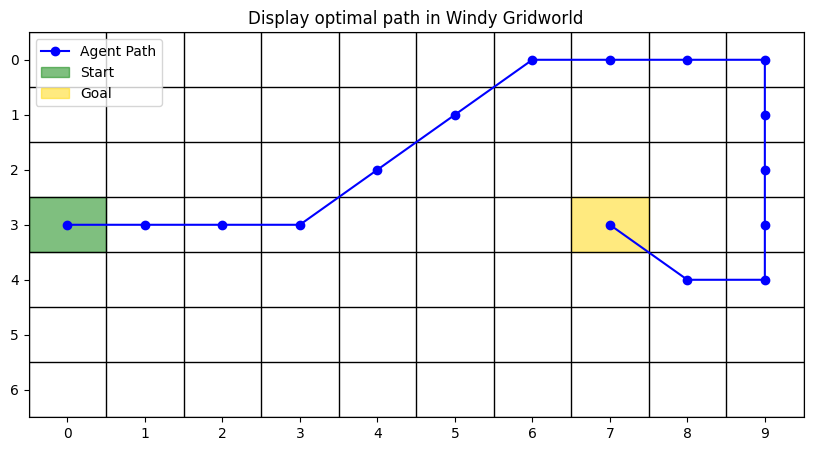

In [21]:
max_reward_indexS = E_GtS.index(max(E_GtS))  # Get index of episode with max reward

optimal_pathS = paths[max_reward_index]  # Path corresponding to max reward
# Plot path for the last episode
plot_path((rows, cols), optimal_pathS, "Display optimal path in Windy Gridworld")

Sarsa gets there quicker but is not stable

## Reflection

Upon my peers comments I found I had been displaying the final path which is not always the optimal one. This was updated.

#### Task 2

***CS5004 DQN Lunar landing Classic Control AY 24/25***


In this task I will look at classic control for lunar landing

This project requires Python 3.10 or above:

In [ ]:
import sys
assert sys.version_info >= (3, 10)

from packaging import version
import tensorflow as tf
assert version.parse(tf.__version__) >= version.parse("2.8.0")

import matplotlib.animation
import matplotlib.pyplot as plt

In [ ]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

In [ ]:
if "google.colab" in sys.modules or "kaggle_secrets" in sys.modules:
    %pip install -q -U gymnasium swig
    %pip install -q -U gymnasium[classic_control,box2d,atari]

import gymnasium as gym

And TensorFlow ≥ 2.8:

Define the default font sizes for plots.